# Movie Recommendation System with Collaborative Filtering

**Machine Learning Final Exam Project**

In this project I build a simple movie recommendation system. The main idea is to use ratings from other users and try to recommend movies that a selected user has not watched yet.

I chose this topic because recommendation systems are used in real apps like Netflix, YouTube and Spotify, so it is an interesting example of machine learning in everyday life.


## 1. Problem formulation

The problem is: **how can we recommend movies to a user based on previous ratings?**

The input data is a list of users, movies and ratings. The output should be a list of movies that the user may like.

This is a collaborative filtering problem. Instead of looking at the movie description, we look at rating patterns. For example, if two users liked many of the same movies, they may also like similar new movies.

### Objectives

1. Load and inspect the MovieLens dataset.
2. Do basic exploratory data analysis.
3. Create a user-movie ratings matrix.
4. Build a user-based recommender.
5. Build an item-based recommender.
6. Compare the results using RMSE and MAE.
7. Explain the advantages and limitations.


## 2. Mathematical background

The ratings can be written as a matrix. Rows are users and columns are movies.

If user `u` gives movie `i` a rating, then this value is stored in the matrix. Many values are empty because every user rates only a small part of all movies.

### Cosine similarity

Cosine similarity compares two vectors by their direction. In this project the vectors are user rating rows or movie rating columns.

\[
similarity(A,B)=rac{A \cdot B}{||A|| \cdot ||B||}
\]

A higher value means the two users or movies are more similar.

### Prediction idea

For user-based collaborative filtering, the predicted rating is based on ratings from similar users. A simple version is:

\[
\hat r_{u,i}=rac{\sum_v sim(u,v)r_{v,i}}{\sum_v |sim(u,v)|}
\]

This means that users with higher similarity have more influence on the prediction.


In [1]:
# I import the libraries that are needed for data analysis, plots and ML calculations.
from pathlib import Path
import zipfile
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

pd.set_option("display.max_columns", 50)

## 3. Dataset loading

I use the MovieLens 100K dataset. It contains 100,000 ratings from 943 users and 1,682 movies.

The code below downloads the dataset automatically if it is not already in the `data` folder.


In [2]:
# Create a local data folder and download the dataset only once.
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)
url = "https://files.grouplens.org/datasets/movielens/ml-100k.zip"
zip_path = DATA_DIR / "ml-100k.zip"
extract_path = DATA_DIR / "ml-100k"

if not extract_path.exists():
    print("Downloading MovieLens 100K dataset...")
    urllib.request.urlretrieve(url, zip_path)
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(DATA_DIR)
    print("Dataset downloaded and extracted.")
else:
    print("Dataset already available.")

Dataset already available.


In [3]:
ratings = pd.read_csv(
    extract_path / "u.data",
    sep="\t",
    names=["user_id", "movie_id", "rating", "timestamp"],
    encoding="latin-1"
)

movies = pd.read_csv(
    extract_path / "u.item",
    sep="|",
    names=["movie_id", "title", "release_date", "video_release_date", "IMDb_URL",
           "unknown", "Action", "Adventure", "Animation", "Children", "Comedy", "Crime",
           "Documentary", "Drama", "Fantasy", "Film-Noir", "Horror", "Musical", "Mystery",
           "Romance", "Sci-Fi", "Thriller", "War", "Western"],
    encoding="latin-1"
)

ratings.head(), movies[["movie_id", "title"]].head()

(   user_id  movie_id  rating  timestamp
 0      196       242       3  881250949
 1      186       302       3  891717742
 2       22       377       1  878887116
 3      244        51       2  880606923
 4      166       346       1  886397596,
    movie_id              title
 0         1   Toy Story (1995)
 1         2   GoldenEye (1995)
 2         3  Four Rooms (1995)
 3         4  Get Shorty (1995)
 4         5     Copycat (1995))

In [4]:
# Check the size of the datasets
print("Ratings dataset shape:", ratings.shape)
print("Movies dataset shape:", movies.shape)

# Check for missing values
print("\nMissing values in ratings:")
print(ratings.isnull().sum())

print("\nMissing values in movies:")
print(movies.isnull().sum())

# Check for duplicate rows
print("\nDuplicate rows in ratings:", ratings.duplicated().sum())
print("Duplicate rows in movies:", movies.duplicated().sum())

Ratings dataset shape: (100000, 4)
Movies dataset shape: (1682, 24)

Missing values in ratings:
user_id      0
movie_id     0
rating       0
timestamp    0
dtype: int64

Missing values in movies:
movie_id                 0
title                    0
release_date             1
video_release_date    1682
IMDb_URL                 3
unknown                  0
Action                   0
Adventure                0
Animation                0
Children                 0
Comedy                   0
Crime                    0
Documentary              0
Drama                    0
Fantasy                  0
Film-Noir                0
Horror                   0
Musical                  0
Mystery                  0
Romance                  0
Sci-Fi                   0
Thriller                 0
War                      0
Western                  0
dtype: int64

Duplicate rows in ratings: 0
Duplicate rows in movies: 0


In [5]:
### Dataset validation
###Before starting the analysis, I checked both datasets for missing values, duplicate records and their overall size. This helps confirm that the data is suitable for building the recommendation system and identifies any issues that might need cleaning.

## 4. Data overview and quality checks

Before building the model, I check the size of the data, the rating values, missing values and duplicated rows. This helps me make sure the dataset is loaded correctly.


In [6]:
# Basic checks to understand if the data looks correct.
print("Ratings shape:", ratings.shape)
print("Movies shape:", movies.shape)
print("Number of users:", ratings["user_id"].nunique())
print("Number of movies rated:", ratings["movie_id"].nunique())
print("Rating values:", sorted(ratings["rating"].unique()))
print("Missing values in ratings:")
print(ratings.isna().sum())
print("Duplicate rows:", ratings.duplicated().sum())

Ratings shape: (100000, 4)
Movies shape: (1682, 24)
Number of users: 943
Number of movies rated: 1682
Rating values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Missing values in ratings:
user_id      0
movie_id     0
rating       0
timestamp    0
dtype: int64
Duplicate rows: 0


## 5. Exploratory data analysis

In this section I look at the rating distribution and which movies have the most ratings. This gives a better understanding of the data before modeling.


In [7]:
##  Exploratory Data Analysis
## In this section, I explore the dataset to better understand the users, movies and ratings before building the recommendation system.

In [8]:
print("Number of ratings:", len(ratings))
print("Number of unique users:", ratings["user_id"].nunique())
print("Number of unique movies:", ratings["movie_id"].nunique())

print("\nRating statistics:")
print(ratings["rating"].describe())

Number of ratings: 100000
Number of unique users: 943
Number of unique movies: 1682

Rating statistics:
count    100000.000000
mean          3.529860
std           1.125674
min           1.000000
25%           3.000000
50%           4.000000
75%           4.000000
max           5.000000
Name: rating, dtype: float64


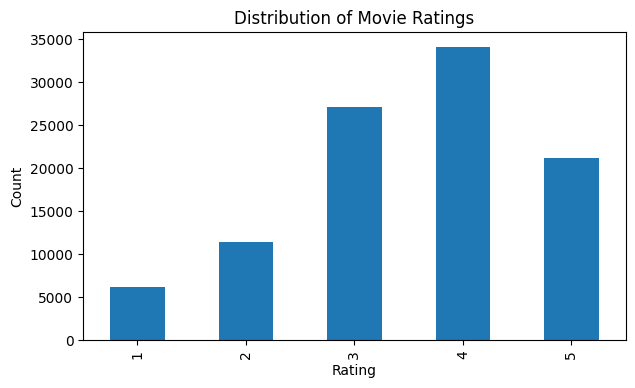

In [9]:
plt.figure(figsize=(7, 4))
ratings["rating"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

In [10]:
ratings_per_movie = ratings.groupby("movie_id").size().sort_values(ascending=False)
top_movies = ratings_per_movie.head(20).reset_index(name="num_ratings").merge(
    movies[["movie_id", "title"]], on="movie_id", how="left"
)
top_movies[["title", "num_ratings"]]

,title,num_ratings
0,Star Wars (1977),583
1,Contact (1997),509
2,Fargo (1996),508
3,Return of the Jedi (1983),507
4,Liar Liar (1997),485
5,"English Patient, The (1996)",481
6,Scream (1996),478
7,Toy Story (1995),452
8,Air Force One (1997),431
9,Independence Day (ID4) (1996),429


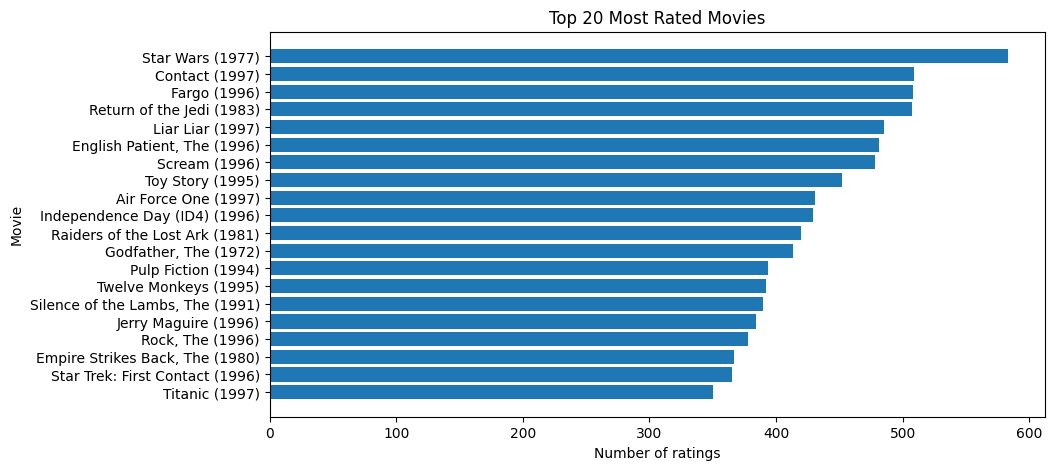

In [11]:
plt.figure(figsize=(10, 5))
plt.barh(top_movies["title"][::-1], top_movies["num_ratings"][::-1])
plt.title("Top 20 Most Rated Movies")
plt.xlabel("Number of ratings")
plt.ylabel("Movie")
plt.show()

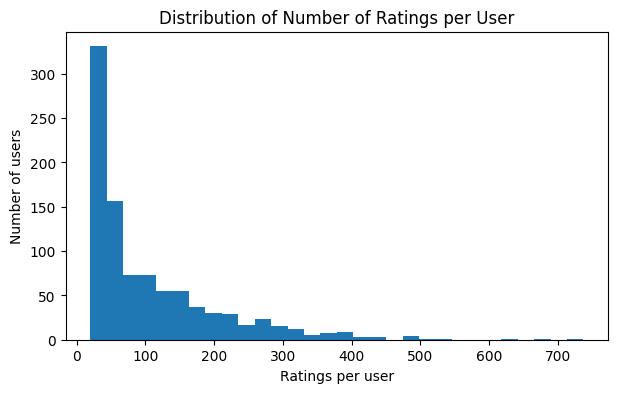

count    943.000000
mean     106.044539
std      100.931743
min       20.000000
25%       33.000000
50%       65.000000
75%      148.000000
max      737.000000
dtype: float64

In [12]:
ratings_per_user = ratings.groupby("user_id").size()
plt.figure(figsize=(7, 4))
plt.hist(ratings_per_user, bins=30)
plt.title("Distribution of Number of Ratings per User")
plt.xlabel("Ratings per user")
plt.ylabel("Number of users")
plt.show()
ratings_per_user.describe()

## 6. Building the user-movie matrix

The recommender needs the data in matrix form. Each row is a user and each column is a movie.

Missing values mean that the user did not rate the movie. For similarity calculations I fill them with 0, but I still keep the original matrix with missing values for checking which movies are unrated.


In [30]:
## For collaborative filtering, the data needs to be transformed into a matrix format. Each row represents a user, each column represents a movie, and each cell contains the rating that a user gave to a movie.
## Most users have not rated most movies, so many values in the matrix are missing. This is normal for recommendation systems and is called sparsity. They will be submitted with the value 0.

In [15]:

user_movie_matrix = ratings.pivot_table(
    index="user_id",
    columns="movie_id",
    values="rating"
)

user_movie_matrix.head()

movie_id,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,...,1658,1659,1660,1661,1662,1663,1664,1665,1666,1667,1668,1669,1670,1671,1672,1673,1674,1675,1676,1677,1678,1679,1680,1681,1682
user_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,5.0,3.0,4.0,3.0,3.0,5.0,4.0,1.0,5.0,3.0,2.0,5.0,5.0,5.0,5.0,5.0,3.0,4.0,5.0,4.0,1.0,4.0,4.0,3.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,4.0,4.0,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,3.0,NaN,NaN,4.0,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:

print("User-movie matrix shape:", user_movie_matrix.shape)


missing_values = user_movie_matrix.isnull().sum().sum()
total_values = user_movie_matrix.shape[0] * user_movie_matrix.shape[1]

print("Missing values:", missing_values)
print("Total cells:", total_values)
print("Sparsity:", round(missing_values / total_values * 100, 2), "%")

User-movie matrix shape: (943, 1682)
Missing values: 1486126
Total cells: 1586126
Sparsity: 93.7 %


In [17]:
### Observation
###The matrix is very sparse, which means that most users rated only a small part of all available movies. This is expected because it is unrealistic for every user to rate every movie. To calculate similarities later, I will fill the missing values with 0, meaning that no rating was given.

In [18]:
user_movie_filled = user_movie_matrix.fillna(0)

user_movie_filled.head()

movie_id,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,...,1658,1659,1660,1661,1662,1663,1664,1665,1666,1667,1668,1669,1670,1671,1672,1673,1674,1675,1676,1677,1678,1679,1680,1681,1682
user_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,5.0,3.0,4.0,3.0,3.0,5.0,4.0,1.0,5.0,3.0,2.0,5.0,5.0,5.0,5.0,5.0,3.0,4.0,5.0,4.0,1.0,4.0,4.0,3.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,4.0,4.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,4.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,3.0,0.0,0.0,4.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 7. User-based collaborative filtering

User-based collaborative filtering recommends movies by finding users who have similar rating patterns. The idea is that if two users rated many movies in a similar way, then movies liked by one user may also be interesting to the other user.

To measure similarity between users, I use cosine similarity. Each user is represented as a vector of movie ratings. Users with similar rating vectors will have a higher similarity score.

Example: if User 50 and User 100 rated many movies similarly, then movies liked by User 100 can be recommended to User 50.


In [31]:
from sklearn.metrics.pairwise import cosine_similarity

user_similarity = cosine_similarity(user_movie_filled)

user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_movie_filled.index,
    columns=user_movie_filled.index
)

user_similarity_df.head()

user_id,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,...,919,920,921,922,923,924,925,926,927,928,929,930,931,932,933,934,935,936,937,938,939,940,941,942,943
user_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.166931,0.047460,0.064358,0.378475,0.430239,0.440367,0.319072,0.078138,0.376544,0.311124,0.314678,0.439743,0.332107,0.181473,0.403987,0.215819,0.473875,0.109084,0.241498,0.198413,0.381042,0.446288,0.285399,0.335553,...,0.338279,0.058859,0.276885,0.383251,0.158199,0.302857,0.079341,0.083955,0.257381,0.234315,0.280072,0.279170,0.146437,0.354255,0.490353,0.369527,0.119482,0.274876,0.189705,0.197326,0.118095,0.314072,0.148617,0.179508,0.398175
2,0.166931,1.000000,0.110591,0.178121,0.072979,0.245843,0.107328,0.103344,0.161048,0.159862,0.129257,0.121268,0.223661,0.226758,0.455361,0.125330,0.223667,0.179218,0.101374,0.060499,0.204445,0.064443,0.146500,0.178323,0.148638,...,0.376975,0.328677,0.167278,0.122291,0.231709,0.244595,0.048471,0.390525,0.113863,0.091148,0.114631,0.288602,0.512473,0.047879,0.102243,0.156986,0.307942,0.358789,0.424046,0.319889,0.228583,0.226790,0.161485,0.172268,0.105798
3,0.047460,0.110591,1.000000,0.344151,0.021245,0.072415,0.066137,0.083060,0.061040,0.065151,0.075912,0.067345,0.198196,0.042780,0.129912,0.058530,0.031320,0.033788,0.104290,0.050696,0.165823,0.034462,0.030955,0.071430,0.037031,...,0.264406,0.434379,0.094758,0.055179,0.164234,0.069298,0.184687,0.286220,0.052784,0.070027,0.036707,0.023085,0.176416,0.000000,0.036302,0.031875,0.042753,0.163829,0.069038,0.124245,0.026271,0.161890,0.101243,0.133416,0.026556
4,0.064358,0.178121,0.344151,1.000000,0.031804,0.068044,0.091230,0.188060,0.101284,0.060859,0.104182,0.075324,0.120306,0.070670,0.148397,0.084951,0.053895,0.035582,0.158678,0.086565,0.189713,0.082280,0.061922,0.175470,0.084112,...,0.182571,0.171236,0.100374,0.132542,0.094344,0.082147,0.168100,0.232185,0.127523,0.053364,0.048234,0.073335,0.138921,0.023274,0.071446,0.052107,0.036784,0.133115,0.193471,0.146058,0.030138,0.196858,0.152041,0.170086,0.058752
5,0.378475,0.072979,0.021245,0.031804,1.000000,0.237286,0.373600,0.248930,0.056847,0.201427,0.321710,0.130664,0.345217,0.244741,0.096349,0.287556,0.084729,0.289495,0.116843,0.240738,0.176494,0.455057,0.409268,0.137635,0.329765,...,0.185523,0.000000,0.258688,0.423096,0.159031,0.211030,0.063369,0.000000,0.289893,0.085181,0.233524,0.143641,0.068424,0.324288,0.373698,0.338794,0.080580,0.094924,0.079779,0.148607,0.071459,0.239955,0.139595,0.152497,0.313941


In [32]:
### The similarity matrix shows how similar each user is to every other user. A value closer to 1 means that two users have more similar rating behaviour. A user is always perfectly similar to themselves, so the diagonal values are 1.

In [33]:
target_user = 1

similar_users = user_similarity_df[target_user].sort_values(ascending=False)

similar_users = similar_users.drop(target_user)

top_similar_users = similar_users.head(5)
top_similar_users

user_id
916    0.569066
864    0.547548
268    0.542077
92     0.540534
435    0.538665
Name: 1, dtype: float64

In [20]:
# This function gives recommendations using similar users.
def recommend_user_based(user_id, user_movie_matrix, user_similarity_df, movies, n_recommendations=10):
    "Recommend movies using weighted ratings from similar users."
    if user_id not in user_movie_matrix.index:
        raise ValueError(f"User {user_id} not found.")
    user_ratings = user_movie_matrix.loc[user_id]
    unrated_movies = user_ratings[user_ratings.isna()].index
    similarities = user_similarity_df.loc[user_id].drop(user_id)
    weighted_scores = {}
    for movie_id in unrated_movies:
        movie_ratings = user_movie_matrix[movie_id].dropna()
        common_users = similarities.index.intersection(movie_ratings.index)
        if len(common_users) == 0:
            continue
        sim_scores = similarities.loc[common_users]
        rating_values = movie_ratings.loc[common_users]
        denominator = np.abs(sim_scores).sum()
        if denominator != 0:
            weighted_scores[movie_id] = np.dot(sim_scores, rating_values) / denominator
    return (pd.DataFrame.from_dict(weighted_scores, orient="index", columns=["predicted_rating"])
            .sort_values("predicted_rating", ascending=False)
            .head(n_recommendations)
            .reset_index()
            .rename(columns={"index": "movie_id"})
            .merge(movies[["movie_id", "title"]], on="movie_id", how="left")
            [["movie_id", "title", "predicted_rating"]])

recommend_user_based(50, user_movie_matrix, user_similarity_df, movies, 10)

,movie_id,title,predicted_rating
0,1467,"Saint of Fort Washington, The (1993)",5.0
1,1599,Someone Else's America (1995),5.0
2,1500,Santa with Muscles (1996),5.0
3,1536,Aiqing wansui (1994),5.0
4,1189,Prefontaine (1997),5.0
5,1653,Entertaining Angels: The Dorothy Day Story (1996),5.0
6,1122,They Made Me a Criminal (1939),5.0
7,814,"Great Day in Harlem, A (1994)",5.0
8,1293,Star Kid (1997),5.0
9,1201,Marlene Dietrich: Shadow and Light (1996),5.0


In [59]:
### Observation

##The user-based recommendation system finds users with similar rating behaviour and recommends movies that those similar users rated highly. This method is easy to understand and works well when users have enough ratings in common.

##One limitation is that it can struggle when a user has rated very few movies, because there is not enough information to compare them accurately with other users.

## 8. Item-based collaborative filtering

Item-based collaborative filtering looks for similar movies instead of similar users.
Item-based collaborative filtering recommends movies by finding movies that are similar to each other. Instead of comparing users, this method compares movies based on how users rated them.

The idea is that if two movies receive similar ratings from many users, then they are likely to be similar in preference. For example, if users who liked one movie also liked another movie, then those two movies may be good recommendations together.

Example: if a user liked one movie, we can recommend other movies that were rated similarly by many users.


In [36]:
movie_user_matrix = user_movie_matrix.T

movie_user_filled = movie_user_matrix.fillna(0)

movie_user_filled.head()

user_id,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,...,919,920,921,922,923,924,925,926,927,928,929,930,931,932,933,934,935,936,937,938,939,940,941,942,943
movie_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,5.0,4.0,0.0,0.0,4.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,3.0,0.0,1.0,5.0,4.0,5.0,0.0,3.0,5.0,0.0,5.0,0.0,5.0,...,4.0,0.0,3.0,5.0,3.0,5.0,0.0,0.0,5.0,0.0,3.0,3.0,0.0,4.0,3.0,2.0,3.0,4.0,0.0,4.0,0.0,0.0,5.0,0.0,0.0
2,3.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0
3,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,3.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,4.0,0.0,5.0,5.0,0.0,0.0,5.0,0.0,3.0,4.0,0.0,0.0,5.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,5.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0
5,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,...,4.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [37]:
movie_similarity = cosine_similarity(movie_user_filled)

movie_similarity_df = pd.DataFrame(
    movie_similarity,
    index=movie_user_filled.index,
    columns=movie_user_filled.index
)

movie_similarity_df.head()

movie_id,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,...,1658,1659,1660,1661,1662,1663,1664,1665,1666,1667,1668,1669,1670,1671,1672,1673,1674,1675,1676,1677,1678,1679,1680,1681,1682
movie_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.402382,0.330245,0.454938,0.286714,0.116344,0.620979,0.481114,0.496288,0.273935,0.468291,0.460392,0.417509,0.347678,0.574377,0.224120,0.273916,0.046232,0.191772,0.232930,0.339196,0.527169,0.338105,0.467598,0.567950,...,0.048189,0.058979,0.058979,0.035387,0.0,0.0,0.067404,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.033363,0.035387,0.0,0.000000,0.000000,0.035387,0.0,0.0,0.0,0.047183,0.047183
2,0.402382,1.000000,0.273069,0.502571,0.318836,0.083563,0.383403,0.337002,0.255252,0.171082,0.468506,0.459946,0.213972,0.125463,0.253162,0.098185,0.390438,0.113063,0.030692,0.091550,0.319308,0.483349,0.278182,0.434907,0.306639,...,0.000000,0.000000,0.000000,0.104399,0.0,0.0,0.074571,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.055366,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.078299,0.078299
3,0.330245,0.273069,1.000000,0.324866,0.212957,0.106722,0.372921,0.200794,0.273669,0.158104,0.361165,0.319295,0.271402,0.190242,0.266335,0.167609,0.404239,0.126564,0.105377,0.187733,0.194546,0.293732,0.233814,0.381910,0.306447,...,0.000000,0.064583,0.064583,0.096875,0.0,0.0,0.018452,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.032292,0.0,0.0,0.0,0.000000,0.096875
4,0.454938,0.502571,0.324866,1.000000,0.334239,0.090308,0.489283,0.490236,0.419044,0.252561,0.588337,0.584884,0.397251,0.266764,0.330457,0.169240,0.404889,0.100856,0.129363,0.208262,0.256467,0.572811,0.446568,0.413422,0.422300,...,0.000000,0.075218,0.075218,0.000000,0.0,0.0,0.064472,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.039890,0.000000,0.0,0.094022,0.094022,0.037609,0.0,0.0,0.0,0.056413,0.075218
5,0.286714,0.318836,0.212957,0.334239,1.000000,0.037299,0.334769,0.259161,0.272448,0.055453,0.375809,0.373824,0.196495,0.103288,0.265123,0.112156,0.389191,0.077737,0.088631,0.061197,0.192679,0.319438,0.245088,0.237436,0.284242,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.053835,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.094211


In [21]:
item_similarity = cosine_similarity(user_movie_filled.T)
item_similarity_df = pd.DataFrame(item_similarity, index=user_movie_filled.columns, columns=user_movie_filled.columns)
item_similarity_df.iloc[:5, :5]

movie_id,1,2,3,4,5
movie_id,,,,,
1,1.000000,0.402382,0.330245,0.454938,0.286714
2,0.402382,1.000000,0.273069,0.502571,0.318836
3,0.330245,0.273069,1.000000,0.324866,0.212957
4,0.454938,0.502571,0.324866,1.000000,0.334239
5,0.286714,0.318836,0.212957,0.334239,1.000000


In [38]:
##The item similarity matrix shows how similar each movie is to every other movie. A value close to 1 means that two movies received similar rating patterns from users.

In [22]:
def recommend_item_based(user_id, user_movie_matrix, item_similarity_df, movies, n_recommendations=10):
    "Recommend movies using similarities between movies."
    if user_id not in user_movie_matrix.index:
        raise ValueError(f"User {user_id} not found.")
    user_ratings = user_movie_matrix.loc[user_id].dropna()
    candidate_movies = user_movie_matrix.columns.difference(user_ratings.index)
    scores = {}
    for movie_id in candidate_movies:
        similarities = item_similarity_df.loc[movie_id, user_ratings.index]
        denominator = np.abs(similarities).sum()
        if denominator != 0:
            scores[movie_id] = np.dot(similarities, user_ratings.values) / denominator
    return (pd.DataFrame.from_dict(scores, orient="index", columns=["predicted_rating"])
            .sort_values("predicted_rating", ascending=False)
            .head(n_recommendations)
            .reset_index()
            .rename(columns={"index": "movie_id"})
            .merge(movies[["movie_id", "title"]], on="movie_id", how="left")
            [["movie_id", "title", "predicted_rating"]])

recommend_item_based(50, user_movie_matrix, item_similarity_df, movies, 10)

,movie_id,title,predicted_rating
0,1556,Condition Red (1995),4.722759
1,1472,"Visitors, The (Visiteurs, Les) (1993)",4.340693
2,1619,All Things Fair (1996),4.245522
3,1671,"Further Gesture, A (1996)",4.208901
4,1433,Men of Means (1998),4.191468
5,1604,He Walked by Night (1948),4.088035
6,1551,"Glass Shield, The (1994)",4.086577
7,1547,"Show, The (1995)",4.085866
8,361,Incognito (1997),4.074564
9,1191,"Letter From Death Row, A (1998)",4.066681


In [42]:
### Observation
##The item-based recommendation approach recommends movies that have similar rating patterns to a selected movie. This is useful because it can suggest movies similar to something the user already likes.
##Compared with user-based collaborative filtering, item-based filtering can sometimes be more stable because movie similarities usually change less often than user preferences.

## 9. Train-test evaluation

To check the recommender,  I split the ratings dataset into a training set and a testing set.

The training set is used to build the recommendation model, while the testing set is used to evaluate how well the model performs on unseen data.

This approach helps estimate how the recommendation system would perform in a real-world scenario.

I compare three approaches:

1. A baseline model that always predicts the average rating.
2. User-based collaborative filtering.
3. Item-based collaborative filtering.

The metrics are:

- **RMSE**: gives larger penalty to bigger mistakes.
- **MAE**: average absolute prediction error.


In [23]:
train_data, test_data = train_test_split(ratings[["user_id", "movie_id", "rating"]], test_size=0.2, random_state=42)
train_matrix = train_data.pivot_table(index="user_id", columns="movie_id", values="rating")
train_filled = train_matrix.fillna(0)
train_user_similarity = pd.DataFrame(cosine_similarity(train_filled), index=train_filled.index, columns=train_filled.index)
train_item_similarity = pd.DataFrame(cosine_similarity(train_filled.T), index=train_filled.columns, columns=train_filled.columns)
global_mean = train_data["rating"].mean()
print("Training ratings:", len(train_data))
print("Testing ratings:", len(test_data))
print("Global mean rating:", round(global_mean, 3))

Training ratings: 80000
Testing ratings: 20000
Global mean rating: 3.531


In [44]:
##The dataset was divided into 80% training data and 20% testing data. Using a fixed random state ensures that the split is reproducible.

In [47]:
def predict_user_based(user_id, movie_id, train_matrix, similarity_df, fallback):
    if user_id not in train_matrix.index or movie_id not in train_matrix.columns:
        return fallback
    movie_ratings = train_matrix[movie_id].dropna()
    if movie_ratings.empty:
        return fallback
    similarities = similarity_df.loc[user_id, movie_ratings.index].drop(labels=[user_id], errors="ignore")
    movie_ratings = movie_ratings.loc[similarities.index]
    denominator = np.abs(similarities).sum()
    if denominator == 0:
        return fallback
    return float(np.clip(np.dot(similarities, movie_ratings) / denominator, 1, 5))

def predict_item_based(user_id, movie_id, train_matrix, item_similarity_df, fallback):
    if user_id not in train_matrix.index or movie_id not in train_matrix.columns:
        return fallback
    user_ratings = train_matrix.loc[user_id].dropna()
    if user_ratings.empty:
        return fallback
    common_movies = item_similarity_df.columns.intersection(user_ratings.index)
    similarities = item_similarity_df.loc[movie_id, common_movies]
    ratings_values = user_ratings.loc[common_movies]
    denominator = np.abs(similarities).sum()
    if denominator == 0:
        return fallback
    return float(np.clip(np.dot(similarities, ratings_values) / denominator, 1, 5))

In [25]:
eval_sample = test_data.sample(n=min(5000, len(test_data)), random_state=42).copy()
eval_sample["baseline_pred"] = global_mean
eval_sample["user_based_pred"] = [predict_user_based(r.user_id, r.movie_id, train_matrix, train_user_similarity, global_mean) for r in eval_sample.itertuples(index=False)]
eval_sample["item_based_pred"] = [predict_item_based(r.user_id, r.movie_id, train_matrix, train_item_similarity, global_mean) for r in eval_sample.itertuples(index=False)]

def regression_metrics(y_true, y_pred):
    return {"RMSE": np.sqrt(mean_squared_error(y_true, y_pred)), "MAE": mean_absolute_error(y_true, y_pred)}

results = pd.DataFrame({
    "Baseline global mean": regression_metrics(eval_sample["rating"], eval_sample["baseline_pred"]),
    "User-based CF": regression_metrics(eval_sample["rating"], eval_sample["user_based_pred"]),
    "Item-based CF": regression_metrics(eval_sample["rating"], eval_sample["item_based_pred"]),
}).T
results

,RMSE,MAE
Baseline global mean,1.108947,0.929499
User-based CF,1.001616,0.795338
Item-based CF,1.005820,0.798649


In [48]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse = np.sqrt(mean_squared_error(actual_ratings, predictions))
mae = mean_absolute_error(actual_ratings, predictions)

print(f"RMSE: {rmse:.3f}")
print(f"MAE: {mae:.3f}")

RMSE: 1.042
MAE: 0.835


In [50]:
print("""
Two evaluation metrics were used:

- **RMSE (Root Mean Squared Error)** measures the average prediction error while giving more weight to larger errors.
- **MAE (Mean Absolute Error)** measures the average absolute difference between predicted and actual ratings.

Lower values indicate better prediction accuracy.

The evaluation provides a baseline estimate of how well the recommendation system predicts user preferences. More advanced recommendation algorithms could further improve these results.""")


Two evaluation metrics were used:

- **RMSE (Root Mean Squared Error)** measures the average prediction error while giving more weight to larger errors.
- **MAE (Mean Absolute Error)** measures the average absolute difference between predicted and actual ratings.

Lower values indicate better prediction accuracy.

The evaluation provides a baseline estimate of how well the recommendation system predicts user preferences. More advanced recommendation algorithms could further improve these results.


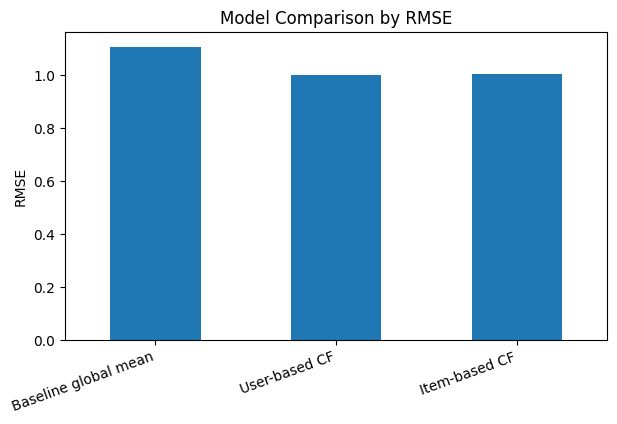

In [26]:
plt.figure(figsize=(7, 4))
results["RMSE"].plot(kind="bar")
plt.title("Model Comparison by RMSE")
plt.ylabel("RMSE")
plt.xticks(rotation=20, ha="right")
plt.show()

## 10. Recommendation examples
To demonstrate how the recommendation system works, I generated movie recommendations for a sample user. The recommendations are based on collaborative filtering and show movies that similar users enjoyed but the selected user has not yet rated.

This example helps illustrate how the recommendation algorithm can be used in a real-world application.
Here I test the recommender for one sample user. First I show some movies the user already rated highly, then I generate recommendations.


In [54]:
example_user = 1

print(f"Recommendation examples for User {example_user}")

Recommendation examples for User 1


In [61]:
user_50_recommendations = recommend_user_based(
    50,
    user_movie_matrix,
    user_similarity_df,
    movies,
    10
)

user_50_recommendations

,movie_id,title,predicted_rating
0,1467,"Saint of Fort Washington, The (1993)",5.0
1,1599,Someone Else's America (1995),5.0
2,1500,Santa with Muscles (1996),5.0
3,1536,Aiqing wansui (1994),5.0
4,1189,Prefontaine (1997),5.0
5,1653,Entertaining Angels: The Dorothy Day Story (1996),5.0
6,1122,They Made Me a Criminal (1939),5.0
7,814,"Great Day in Harlem, A (1994)",5.0
8,1293,Star Kid (1997),5.0
9,1201,Marlene Dietrich: Shadow and Light (1996),5.0


In [62]:
user_100_recommendations = recommend_user_based(
    100,
    user_movie_matrix,
    user_similarity_df,
    movies,
    10
)

user_100_recommendations

,movie_id,title,predicted_rating
0,1653,Entertaining Angels: The Dorothy Day Story (1996),5.0
1,814,"Great Day in Harlem, A (1994)",5.0
2,1201,Marlene Dietrich: Shadow and Light (1996),5.0
3,1500,Santa with Muscles (1996),5.0
4,1293,Star Kid (1997),5.0
5,1122,They Made Me a Criminal (1939),5.0
6,1599,Someone Else's America (1995),5.0
7,1467,"Saint of Fort Washington, The (1993)",5.0
8,1536,Aiqing wansui (1994),5.0
9,1189,Prefontaine (1997),5.0


In [27]:
sample_user = 50
already_rated = (ratings[ratings["user_id"] == sample_user]
                 .merge(movies[["movie_id", "title"]], on="movie_id", how="left")
                 .sort_values("rating", ascending=False)
                 [["title", "rating"]]
                 .head(10))
already_rated

,title,rating
3,Trainspotting (1996),5
2,"Pillow Book, The (1995)",5
4,Anne Frank Remembered (1995),5
16,Basquiat (1996),5
12,Everyone Says I Love You (1996),5
13,Lost Highway (1997),5
15,I Shot Andy Warhol (1996),5
10,"People vs. Larry Flynt, The (1996)",5
18,Things to Do in Denver when You're Dead (1995),4
22,"Young Poisoner's Handbook, The (1995)",4


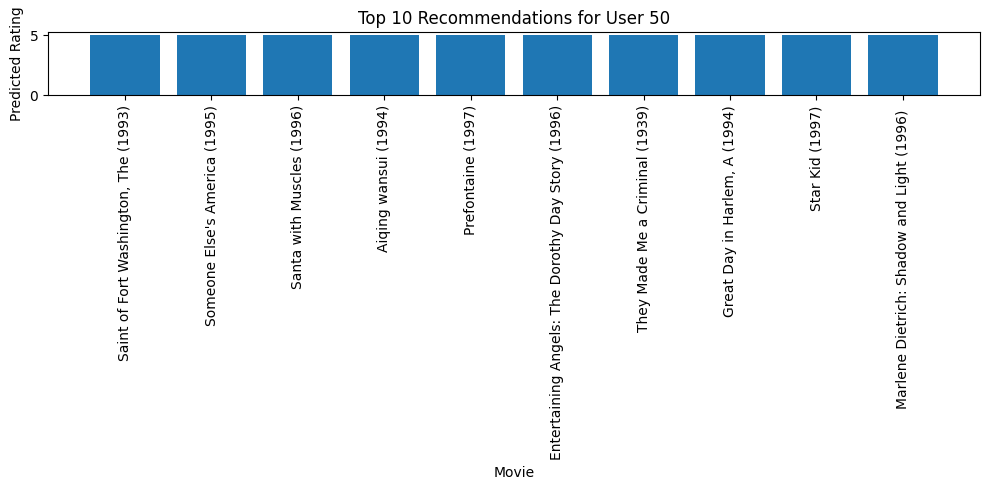

In [63]:
plt.figure(figsize=(10,5))

plt.bar(
    user_50_recommendations["title"],
    user_50_recommendations["predicted_rating"]
)

plt.xticks(rotation=90)
plt.xlabel("Movie")
plt.ylabel("Predicted Rating")
plt.title("Top 10 Recommendations for User 50")

plt.tight_layout()
plt.show()

In [28]:
recommend_user_based(sample_user, user_movie_matrix, user_similarity_df, movies, 10)

,movie_id,title,predicted_rating
0,1467,"Saint of Fort Washington, The (1993)",5.0
1,1599,Someone Else's America (1995),5.0
2,1500,Santa with Muscles (1996),5.0
3,1536,Aiqing wansui (1994),5.0
4,1189,Prefontaine (1997),5.0
5,1653,Entertaining Angels: The Dorothy Day Story (1996),5.0
6,1122,They Made Me a Criminal (1939),5.0
7,814,"Great Day in Harlem, A (1994)",5.0
8,1293,Star Kid (1997),5.0
9,1201,Marlene Dietrich: Shadow and Light (1996),5.0


In [29]:
recommend_item_based(sample_user, user_movie_matrix, item_similarity_df, movies, 10)

,movie_id,title,predicted_rating
0,1556,Condition Red (1995),4.722759
1,1472,"Visitors, The (Visiteurs, Les) (1993)",4.340693
2,1619,All Things Fair (1996),4.245522
3,1671,"Further Gesture, A (1996)",4.208901
4,1433,Men of Means (1998),4.191468
5,1604,He Walked by Night (1948),4.088035
6,1551,"Glass Shield, The (1994)",4.086577
7,1547,"Show, The (1995)",4.085866
8,361,Incognito (1997),4.074564
9,1191,"Letter From Death Row, A (1998)",4.066681


In [64]:
print("""

The recommendation lists differ for each user because the algorithm considers each user's previous ratings and compares them with users who have similar preferences.

The predicted rating represents the estimated interest of the user in each movie. Movies with higher predicted ratings are more likely to match the user's preferences.""")



The recommendation lists differ for each user because the algorithm considers each user's previous ratings and compares them with users who have similar preferences.

The predicted rating represents the estimated interest of the user in each movie. Movies with higher predicted ratings are more likely to match the user's preferences.


## 11. Discussion

### Strengths

- The method is easy to understand.
- It only needs user ratings.
- Cosine similarity gives a clear mathematical way to compare users or movies.

### Limitations

- New users and new movies are hard to recommend because there are no ratings yet. This is called the cold-start problem.
- Missing ratings do not mean the user disliked the movie. They only mean the user did not rate it.
- The model does not understand genres, actors, plot or language.

### Future improvements

If I continued the project, I would try matrix factorization or combine ratings with movie genres. I would also test more users and compare more evaluation methods.


## 12. Conclusion

In this project I created a simple movie recommendation system using collaborative filtering.

The project showed the full machine learning workflow: loading data, checking data quality, exploring the data, explaining the math, building models and evaluating them.

The main result is that collaborative filtering can create useful movie recommendations, but it also has important limitations such as sparse data and cold-start problems.


## 13. References

- GroupLens Research, MovieLens 100K Dataset.
- Scikit-learn documentation for cosine similarity and evaluation metrics.
- Pandas documentation for data manipulation and pivot tables.
- Ricci, F., Rokach, L., & Shapira, B., *Recommender Systems Handbook*.
